In [46]:
!pip install -q minigrid
!pip install -q stable-baselines3
!pip install -q gymnasium
!pip install -q imageio

In [47]:
import gymnasium as gym
import minigrid

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [48]:
import gymnasium as gym
from minigrid.wrappers import FlatObsWrapper

env = gym.make("MiniGrid-DoorKey-8x8-v0")

env = FlatObsWrapper(env)

print("Environment Type:")
print(type(env))

print("\nObservation Space:")
print(env.observation_space)

obs, info = env.reset()

print("\nObservation Type:")
print(type(obs))

print("\nObservation Shape:")
print(obs.shape)

Environment Type:
<class 'minigrid.wrappers.FlatObsWrapper'>

Observation Space:
Box(0, 255, (2835,), uint8)

Observation Type:
<class 'numpy.ndarray'>

Observation Shape:
(2835,)


In [54]:
import gymnasium as gym
from minigrid.wrappers import FlatObsWrapper

env = gym.make("MiniGrid-DoorKey-8x8-v0")
env = FlatObsWrapper(env)

print(type(env))
print(env.observation_space)

<class 'minigrid.wrappers.FlatObsWrapper'>
Box(0, 255, (2835,), uint8)


In [55]:
obs, info = env.reset()

print(type(obs))
print(obs.shape if hasattr(obs, "shape") else "NO SHAPE")
print(obs[:10] if hasattr(obs, "__getitem__") else obs)

<class 'numpy.ndarray'>
(2835,)
[0 0 0 0 0 0 0 0 0 0]


In [51]:
env = gym.make(ENV_NAME)

env = Monitor(env)

print("Observation Space:")
print(env.observation_space)

print("\nAction Space:")
print(env.action_space)

Observation Space:
Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function DoorKeyEnv._gen_mission at 0x7bdcf9e7b7e0>, None))

Action Space:
Discrete(7)


In [52]:
obs, info = env.reset()

for _ in range(5):
    
    action = env.action_space.sample()
    
    obs, reward, terminated, truncated, info = env.step(action)

    print("Action:", action)
    print("Reward:", reward)

    if terminated or truncated:
        obs, info = env.reset()

Action: 0
Reward: 0
Action: 6
Reward: 0
Action: 1
Reward: 0
Action: 5
Reward: 0
Action: 4
Reward: 0


In [53]:
from stable_baselines3.common.env_checker import check_env

check_env(env)
print("CHECK PASSED")

AssertionError: Error while checking key=mission: The observation returned by `reset()` method must be a numpy array

In [11]:
print(env.observation_space)

Box(0, 255, (2835,), uint8)


In [56]:
from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99
)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [34]:
from minigrid.wrappers import *

print(dir())

['ActionBonus', 'ActionWrapper', 'Any', 'COLOR_TO_IDX', 'DictObservationSpaceWrapper', 'DirectionObsWrapper', 'ENV_NAME', 'FlatObsWrapper', 'FullyObsWrapper', 'Goal', 'ImgObsWrapper', 'In', 'Monitor', 'NoDeath', 'OBJECT_TO_IDX', 'ObsType', 'ObservationWrapper', 'OneHotPartialObsWrapper', 'Out', 'PPO', 'Path', 'PositionBonus', 'RGBImgObsWrapper', 'RGBImgPartialObsWrapper', 'ReseedWrapper', 'STATE_TO_IDX', 'StochasticActionWrapper', 'SymbolicObsWrapper', 'TIMESTEPS', 'ViewSizeWrapper', 'Wrapper', '_', '_13', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'action', 'annotations', 'env', 'evaluate_agent', 'exit', 'fi

In [61]:
TIMESTEPS = 200000

model.learn(
    total_timesteps=TIMESTEPS
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 640      |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 627      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 640         |
|    ep_rew_mean          | 0           |
| time/                   |             |
|    fps                  | 520         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015958719 |
|    clip_fraction        | 0.199       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.67       |
|    explained_variance   | -1.82       |
|    learning_rate        | 0.

In [58]:
model.save(
    "results/models/ppo_baseline"
)

print("Model Saved!")

Model Saved!


In [62]:
def evaluate_agent(model, env, episodes=50):

    rewards = []

    for episode in range(episodes):

        obs, info = env.reset()

        done = False

        total_reward = 0

        while not done:

            action, _ = model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward

            done = terminated or truncated

        rewards.append(total_reward)

    return rewards

In [63]:
scores = evaluate_agent(
    model,
    env,
    episodes=50
)

print("Average Reward:", np.mean(scores))
print("Max Reward:", np.max(scores))
print("Min Reward:", np.min(scores))

Average Reward: 0.0
Max Reward: 0
Min Reward: 0


In [17]:
scores = evaluate_agent(
    model,
    env,
    episodes=50
)

print("Average Reward:", np.mean(scores))
print("Max Reward:", np.max(scores))
print("Min Reward:", np.min(scores))

Average Reward: 0.961328125
Max Reward: 0.961328125
Min Reward: 0.961328125


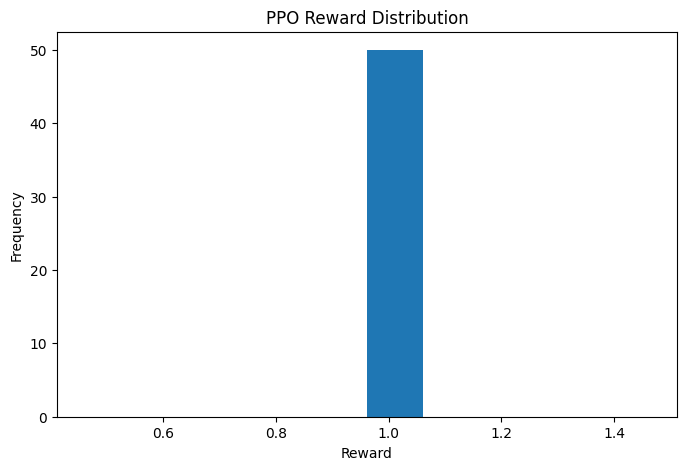

In [18]:
plt.figure(figsize=(8,5))

plt.hist(scores)

plt.title("PPO Reward Distribution")

plt.xlabel("Reward")

plt.ylabel("Frequency")

plt.show()

In [20]:
import os

file_path = "results/tables"

# Create parent directories if they don't exist
os.makedirs(os.path.dirname(file_path), exist_ok=True)

In [22]:
results = pd.DataFrame(
    {
        "reward": scores
    }
)

results.to_csv(
    "results/ppo_results.csv",
    index=False
)

print("Results Saved!")

Results Saved!
